In [1]:
!pip install -q \
langgraph \
langchain-core \
langchain-community \
langchain-huggingface \
langchain-text-splitters \
transformers \
accelerate \
sentence-transformers \
chromadb \
pydantic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 

In [2]:
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 31.1 MB/s eta 0:00:00


In [3]:
import os
import json
import torch
from typing import TypedDict, List, Any
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_core.output_parsers import PydanticOutputParser # NEW: For local structured output

# --- IMPORTS FOR LOCAL LLM ---
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace

# --- IMPORTS FOR MD FILES ---
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma


/tmp/ipykernel_1009/2360489441.py:18: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


In [4]:
from huggingface_hub import login
login(token="hf_lU..........EoLDR")

In [ ]:

# ---------------------------------------------------------
# 0. SETUP LOCAL LLM (4-BIT QUANTIZATION) FOR LLAMA 3.1
# ---------------------------------------------------------
print("Loading local Llama-3.1-8B-Instruct in 4-bit...")

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

# Configure 4-bit quantization to fit easily on a standard GPU (like Google Colab T4)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

# Create the text-generation pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    return_full_text=False
)

hf_llm = HuggingFacePipeline(pipeline=pipe)
llm = ChatHuggingFace(llm=hf_llm)


In [6]:

# ---------------------------------------------------------
# 1. DEFINE THE STRUCTURED OUTPUT SCHEMA (PYDANTIC)
# ---------------------------------------------------------
class Source(BaseModel):
    document: str = Field(description="The name of the document file, e.g., 'workspace-settings.md'")
    passage: str = Field(description="Relevant excerpt or passage identifier from the text")

class VerificationOutput(BaseModel):
    classification: str = Field(description="'answerable' if the answer is completely grounded in context, or 'unanswerable' if hallucinated")
    answer: str = Field(description="The final verified and corrected response")
    sources: List[Source] = Field(description="List of sources backing up the answer")
    confidence: float = Field(description="Confidence score between 0.0 and 1.0")
    requires_human: bool = Field(description="Boolean indicating if human agent is required")
    reason: str = Field(description="Brief explanation of the evaluation")

output_parser = PydanticOutputParser(pydantic_object=VerificationOutput)

# ---------------------------------------------------------
# 2. SETUP: Markdown Loading, Embedding, and Vector Store
# ---------------------------------------------------------
def setup_retriever(file_paths: List[str]):
    print("Loading documents and creating embeddings...")
    docs = []
    for path in file_paths:
        try:
            loader = TextLoader(path)
            docs.extend(loader.load())
            print(f"Successfully loaded: {path}")
        except Exception as e:
            print(f"Warning: Could not load {path} - {e}")

    if not docs:
        raise ValueError("No documents were successfully loaded!")

    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    splits = text_splitter.split_documents(docs)

    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
    vectorstore = Chroma.from_documents(documents=splits, embedding=embeddings)

    return vectorstore.as_retriever(search_kwargs={"k": 5})

md_files_list = [
    "/content/01_product_overview.md",
    "/content/02_roles_and_permissions.md",
    "/content/03_workspace_settings_and_timezones.md",
    "/content/04_scheduled_exports.md",
    "/content/05_api_credentials.md",
    "/content/06_connections_and_refreshes.md",
    "/content/07_delivery_destinations.md",
    "/content/08_escalation_and_diagnostics.md",
    "/content/09_audit_logs.md",
    "/content/10_security_and_safe_responses.md"
]

try:
    retriever = setup_retriever(md_files_list)
    print("Vector store ready!")
except Exception as e:
    print(f"Error initializing vector store (ensure markdown files exist or update paths): {e}")
    retriever = None

# ---------------------------------------------------------
# 3. DEFINE THE GRAPH STATE
# ---------------------------------------------------------
class GraphState(TypedDict):
    question: str
    documents: List[Any]
    loop_count: int
    clarification_count: int
    final_answer: str

# ---------------------------------------------------------
# 4. DEFINE THE NODES
# ---------------------------------------------------------
def question_asked(state: GraphState):
    print("\n---NODE: QUESTION ASKED---")
    return {"question": state["question"], "loop_count": 0, "clarification_count": state.get("clarification_count", 0)}

def out_of_context(state: GraphState):
    print("\n---NODE: OUT OF CONTEXT---")
    return {"final_answer": "Out of the context sir."}

def search_document(state: GraphState):
    print("\n---NODE: SEARCH DOCUMENT---")
    question = state["question"]
    loop_count = state.get("loop_count", 0)
    docs = retriever.invoke(question) if retriever else []
    return {"documents": docs, "loop_count": loop_count + 1}

def generate_answer(state: GraphState):
    print("\n---NODE: GENERATE ANSWER (YES)---")
    question = state["question"]
    docs = state["documents"]
    context = "\n\n".join([d.page_content for d in docs])

    prompt = f"""Use the following context to answer the question.
    Context: {context}
    Question: {question}
    Answer:"""

    response = llm.invoke([HumanMessage(content=prompt)])
    return {"final_answer": response.content}

def verify_answer(state: GraphState):
    print("\n---NODE: VERIFICATION (CHECKING FOR HALLUCINATION & FORMATTING JSON)---")
    question = state["question"]
    docs = state["documents"]
    draft_answer = state["final_answer"]

    context_str = ""
    for d in docs:
        doc_name = d.metadata.get('source', 'Unknown Document')
        context_str += f"Document: {doc_name}\nPassage: {d.page_content}\n\n"

    format_instructions = output_parser.get_format_instructions()

    prompt = f"""You are an AI auditor. Review the 'Draft Answer' against the 'Question' and 'Context Documents'.
    Check if the AI hallucinated or if the answer is completely grounded in the context.

    Question: {question}
    Context Documents:
    {context_str}
    Draft Answer: {draft_answer}

    {format_instructions}

    Ensure your output is strictly valid JSON without any markdown code block ticks if possible, or parseable directly.
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    try:
        parsed_output = output_parser.invoke(response.content)
        final_json_string = parsed_output.model_dump_json(indent=2)
    except Exception as e:
        print(f"\n[Warning] Model struggled with raw JSON formatting. Fallback triggered. Error: {e}")
        final_json_string = json.dumps({
            "error": "Failed to parse structured output cleanly",
            "raw_model_output": response.content
        }, indent=2)

    return {"final_answer": final_json_string}

def human_agent_help(state: GraphState):
    print("\n---NODE: HUMAN AGENT ESCALATION (NO)---")
    return {"final_answer": "I don't have enough information. I might need a human agent's help. I am summarizing and emailing this to HR."}

def generate_suggestions(state: GraphState):
    print("\n---NODE: GENERATE SUGGESTIONS (MAYBE)---")
    question = state["question"]
    docs = state["documents"]
    context = "\n".join([d.page_content for d in docs])

    prompt = f"""The user asked: '{question}'.
    Based on the context, we are close but need clarification.
    Context: {context}
    Suggest exactly 5 similar or related questions the user might have meant, based ONLY on the context provided.
    Format as a simple numbered list."""

    response = llm.invoke([HumanMessage(content=prompt)])
    print("\n[AI]: I need some clarification. Did you mean one of these?")
    print(response.content)

    return {"clarification_count": state.get("clarification_count", 0) + 1}

# ---------------------------------------------------------
# 5. DEFINE CONDITIONAL EDGES
# ---------------------------------------------------------
def check_domain(state: GraphState) -> str:
    print("\n---EDGE: CHECKING DOMAIN---")
    question = state["question"]
    prompt = f"""Is the following question broadly related to a company, software product, HR, workspace settings, APIs, data, or business operations?
    Question: {question}
    Respond with ONLY ONE WORD:
    - "yes" if it is related.
    - "no" if it is completely unrelated."""

    response = llm.invoke([HumanMessage(content=prompt)])
    if "yes" in response.content.strip().lower():
        return "yes"
    return "no"

def decide_relevance(state: GraphState) -> str:
    print("\n---EDGE: DECIDE RELEVANCE---")
    question = state["question"]
    clarification_count = state.get("clarification_count", 0)
    context = "\n".join([d.page_content for d in state["documents"]])

    if not context:
        return "no"

    prompt = f"""You are a grader assessing if the context is sufficient to answer the question.
    Context: {context}
    Question: {question}
    Respond with ONLY ONE WORD:
    - "yes" if the context answers the question.
    - "no" if irrelevant.
    - "maybe" if somewhat relevant but needs clarification."""

    response = llm.invoke([HumanMessage(content=prompt)])
    grade = response.content.strip().lower()

    if "yes" in grade:
        return "yes"
    elif "maybe" in grade:
        if clarification_count >= 1:
            return "no"
        return "maybe"
    else:
        return "no"

# ---------------------------------------------------------
# 6. BUILD, ADD CHECKPOINTER, AND COMPILE
# ---------------------------------------------------------
workflow = StateGraph(GraphState)

workflow.add_node("question_asked", question_asked)
workflow.add_node("out_of_context", out_of_context)
workflow.add_node("search_document", search_document)
workflow.add_node("answer", generate_answer)
workflow.add_node("verify_answer", verify_answer)
workflow.add_node("human_agent_help", human_agent_help)
workflow.add_node("generate_suggestions", generate_suggestions)

workflow.set_entry_point("question_asked")

workflow.add_conditional_edges("question_asked", check_domain, {"yes": "search_document", "no": "out_of_context"})
workflow.add_conditional_edges("search_document", decide_relevance, {"yes": "answer", "maybe": "generate_suggestions", "no": "human_agent_help"})

workflow.add_edge("generate_suggestions", "search_document")
workflow.add_edge("out_of_context", END)
workflow.add_edge("answer", "verify_answer")
workflow.add_edge("verify_answer", END)
workflow.add_edge("human_agent_help", END)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory, interrupt_after=["generate_suggestions"])

# ---------------------------------------------------------
# 7. RUN THE GRAPH
# ---------------------------------------------------------
if __name__ == "__main__":
    if retriever:
        user_input = input("\nEnter your question: ")

        inputs = {"question": user_input, "loop_count": 0, "clarification_count": 0}
        config = {"configurable": {"thread_id": "user_session_1"}}

        for output in app.stream(inputs, config=config):
            pass

        state = app.get_state(config)
        if state.next and state.next[0] == "search_document":
            new_question = input("\nPlease clarify your question (or copy/paste a suggestion): ")
            app.update_state(config, {"question": new_question})

            print("\n--- RESUMING WORKFLOW ---")
            for output in app.stream(None, config=config):
                pass

        print("\n================ FINAL LLM OUTPUT ================\n")
        final_state = app.get_state(config)
        print(final_state.values.get("final_answer", "No answer generated."))
        print("\n==================================================")

Loading documents and creating embeddings...
Successfully loaded: /content/01_product_overview.md
Successfully loaded: /content/02_roles_and_permissions.md
Successfully loaded: /content/03_workspace_settings_and_timezones.md
Successfully loaded: /content/04_scheduled_exports.md
Successfully loaded: /content/05_api_credentials.md
Successfully loaded: /content/06_connections_and_refreshes.md
Successfully loaded: /content/07_delivery_destinations.md
Successfully loaded: /content/08_escalation_and_diagnostics.md
Successfully loaded: /content/09_audit_logs.md
Successfully loaded: /content/10_security_and_safe_responses.md


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Vector store ready!

Enter your question: how is deepika

---NODE: QUESTION ASKED---

---EDGE: CHECKING DOMAIN---


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



---NODE: OUT OF CONTEXT---

================ FINAL LLM OUTPUT ================

Out of the context sir.



In [23]:
if __name__ == "__main__":
    if retriever:
        user_input = input("\nEnter your question: ")

        inputs = {"question": user_input, "loop_count": 0, "clarification_count": 0}
        config = {"configurable": {"thread_id": "user_session_1"}}

        for output in app.stream(inputs, config=config):
            pass

        state = app.get_state(config)
        if state.next and state.next[0] == "search_document":
            new_question = input("\nPlease clarify your question (or copy/paste a suggestion): ")
            app.update_state(config, {"question": new_question})

            print("\n--- RESUMING WORKFLOW ---")
            for output in app.stream(None, config=config):
                pass

        print("\n================ FINAL LLM OUTPUT ================\n")
        final_state = app.get_state(config)
        print(final_state.values.get("final_answer", "No answer generated."))
        print("\n==================================================")


Enter your question: how is Deepika Padukone 


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



---NODE: QUESTION ASKED---

---EDGE: CHECKING DOMAIN---

---NODE: OUT OF CONTEXT---

================ FINAL LLM OUTPUT ================

Out of the context sir.



In [30]:
if __name__ == "__main__":
    if retriever:
        user_input = input("\nEnter your question: ")

        inputs = {"question": user_input, "loop_count": 0, "clarification_count": 0}
        config = {"configurable": {"thread_id": "user_session_1"}}

        for output in app.stream(inputs, config=config):
            pass

        state = app.get_state(config)
        if state.next and state.next[0] == "search_document":
            new_question = input("\nPlease clarify your question (or copy/paste a suggestion): ")
            app.update_state(config, {"question": new_question})

            print("\n--- RESUMING WORKFLOW ---")
            for output in app.stream(None, config=config):
                pass

        print("\n================ FINAL LLM OUTPUT ================\n")
        final_state = app.get_state(config)
        print(final_state.values.get("final_answer", "No answer generated."))
        print("\n==================================================")


Enter your question: The suggested solution did not work. What information should I collect before  escalating?


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



---NODE: QUESTION ASKED---

---EDGE: CHECKING DOMAIN---


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



---NODE: SEARCH DOCUMENT---

---EDGE: DECIDE RELEVANCE---


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



---NODE: GENERATE ANSWER (YES)---


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



---NODE: VERIFICATION (CHECKING FOR HALLUCINATION & FORMATTING JSON)---

================ FINAL LLM OUTPUT ================

{
  "classification": "answerable",
  "answer": "Before escalating, please collect the following information: a detailed description of the issue, steps to reproduce the issue, error logs or relevant output, screenshots or images, affected feature or service, and relevant documentation or records.",
  "sources": [
    {
      "document": "08_escalation_and_diagnostics.md",
      "passage": "Information to Collect"
    },
    {
      "document": "01_product_overview.md",
      "passage": "Support Boundaries"
    },
    {
      "document": "08_escalation_and_diagnostics.md",
      "passage": "Do not request or include:"
    }
  ],
  "confidence": 1.0,
  "requires_human": false,
  "reason": "The information to collect before escalating is clearly stated in the escalation conditions and information to collect sections of the provided documents."
}



In [31]:
if __name__ == "__main__":
    if retriever:
        user_input = input("\nEnter your question: ")

        inputs = {"question": user_input, "loop_count": 0, "clarification_count": 0}
        config = {"configurable": {"thread_id": "user_session_1"}}

        # 1. Start the graph
        for output in app.stream(inputs, config=config):
            pass

        # 2. Check if the graph paused because it needs human clarification
        state = app.get_state(config)
        if state.next and state.next[0] == "search_document":

            # The graph is paused! Get input from the user
            new_question = input("\nPlease clarify your question (or copy/paste a suggestion): ")

            # Update the graph state with the newly clarified question
            app.update_state(config, {"question": new_question})

            # Resume the graph from where it paused
            print("\n--- RESUMING WORKFLOW ---")
            for output in app.stream(None, config=config):
                pass

        # 3. Print final results
        print("\n================ FINAL LLM OUTPUT ================\n")
        final_state = app.get_state(config)
        print(final_state.values.get("final_answer", "No answer generated."))
        print("\n==================================================")


Enter your question: can u give me my 400 dollar back plz


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



---NODE: QUESTION ASKED---

---EDGE: CHECKING DOMAIN---

---NODE: OUT OF CONTEXT---

================ FINAL LLM OUTPUT ================

Out of the context sir.



In [33]:
if __name__ == "__main__":
    if retriever:
        user_input = input("\nEnter your question: ")

        inputs = {"question": user_input, "loop_count": 0, "clarification_count": 0}
        config = {"configurable": {"thread_id": "user_session_1"}}

        # 1. Start the graph
        for output in app.stream(inputs, config=config):
            pass

        # 2. Check if the graph paused because it needs human clarification
        state = app.get_state(config)
        if state.next and state.next[0] == "search_document":

            # The graph is paused! Get input from the user
            new_question = input("\nPlease clarify your question (or copy/paste a suggestion): ")

            # Update the graph state with the newly clarified question
            app.update_state(config, {"question": new_question})

            # Resume the graph from where it paused
            print("\n--- RESUMING WORKFLOW ---")
            for output in app.stream(None, config=config):
                pass

        # 3. Print final results
        print("\n================ FINAL LLM OUTPUT ================\n")
        final_state = app.get_state(config)
        print(final_state.values.get("final_answer", "No answer generated."))
        print("\n==================================================")


Enter your question: This request is intentionally outside the knowledge  base and should be handled safely


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



---NODE: QUESTION ASKED---

---EDGE: CHECKING DOMAIN---


[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



---NODE: SEARCH DOCUMENT---

---EDGE: DECIDE RELEVANCE---

---NODE: HUMAN AGENT ESCALATION (NO)---

================ FINAL LLM OUTPUT ================

I don't have enough information. I might need a human agent's help. I am summarizing and emailing this to HR.



In [ ]:
if __name__ == "__main__":
    if retriever:
        user_input = input("\nEnter your question: ")

        inputs = {"question": user_input, "loop_count": 0, "clarification_count": 0}
        config = {"configurable": {"thread_id": "user_session_1"}}

        # 1. Start the graph
        for output in app.stream(inputs, config=config):
            pass

        # 2. Check if the graph paused because it needs human clarification
        state = app.get_state(config)
        if state.next and state.next[0] == "search_document":

            # The graph is paused! Get input from the user
            new_question = input("\nPlease clarify your question (or copy/paste a suggestion): ")

            # Update the graph state with the newly clarified question
            app.update_state(config, {"question": new_question})

            # Resume the graph from where it paused
            print("\n--- RESUMING WORKFLOW ---")
            for output in app.stream(None, config=config):
                pass

        # 3. Print final results
        print("\n================ FINAL LLM OUTPUT ================\n")
        final_state = app.get_state(config)
        print(final_state.values.get("final_answer", "No answer generated."))
        print("\n==================================================")


Enter your question: The suggested solution did not work. What information should I collect before  escalating

---NODE: QUESTION ASKED---

---EDGE: CHECKING DOMAIN---
DECISION: Question is company related -> Proceeding to search

---NODE: SEARCH DOCUMENT---
Searching existing vector store (No new embeddings are created)...

---EDGE: DECIDE RELEVANCE---
DECISION: Need more info -> MAYBE (Asking user for clarification)

---NODE: GENERATE SUGGESTIONS (MAYBE)---

[AI]: I need some clarification. Did you mean one of these?
1. What are the conditions that require escalation to a human support team?
2. How should I summarize the evidence when escalating an issue?
3. What type of information should I collect before escalating a problem?
4. What are the guidelines for requesting clarification when the retrieved evidence is insufficient?
5. Under what circumstances should I promise a resolution time when responding to an escalation?

Please clarify your question (or copy/paste a suggestion): W

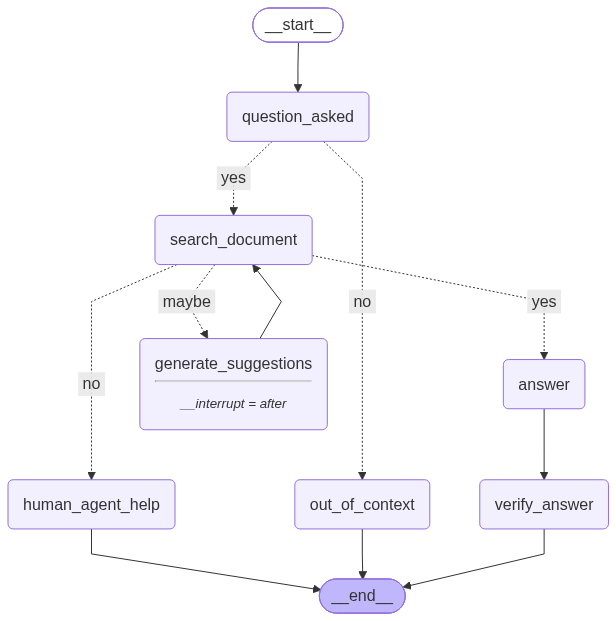

In [11]:
app